<a href="https://colab.research.google.com/github/joseevitor/Detectando_PlacasdeCarro/blob/main/Placas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!sudo apt install tesseract-ocr

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 3 not upgraded.


In [10]:
!pip install pytesseract


In [11]:
!mkdir tessdata

mkdir: cannot create directory ‘tessdata’: File exists


In [12]:
!wget -O ./tessdata/por.traineddata https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true

--2026-07-19 20:53:26--  https://github.com/tesseract-ocr/tessdata/blob/main/por.traineddata?raw=true
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata [following]
--2026-07-19 20:53:26--  https://github.com/tesseract-ocr/tessdata/raw/refs/heads/main/por.traineddata
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata [following]
--2026-07-19 20:53:27--  https://raw.githubusercontent.com/tesseract-ocr/tessdata/refs/heads/main/por.traineddata
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.1

# Bibliiotecas

In [13]:
import cv2
import pytesseract
from google.colab.patches import cv2_imshow

In [14]:
cv2.__version__

'4.13.0'

In [15]:
pytesseract.__version__

'0.3.13'

# Leitura da imagem

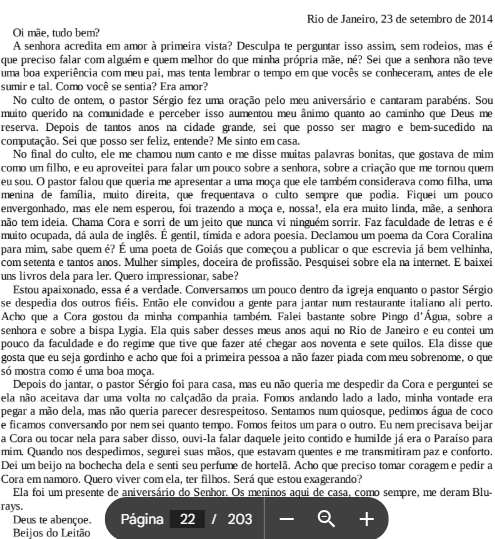

In [16]:
image = cv2.imread("/content/jantar_secreto.png")
cv2_imshow(image)

In [17]:
config_tesseract = "--tessdata-dir tessdata --psm"


In [18]:
!tesseract --list-langs

List of available languages (2):
eng
osd


In [19]:
!apt-get install tesseract-ocr-por

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-por
0 upgraded, 1 newly installed, 0 to remove and 3 not upgraded.
Need to get 856 kB of archives.
After this operation, 1,998 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-por all 1:4.00~git30-7274cfa-1.1 [856 kB]
Fetched 856 kB in 1s (1,091 kB/s)
Selecting previously unselected package tesseract-ocr-por.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-por_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-por (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-por (1:4.00~git30-7274cfa-1.1) ...


In [20]:
text = pytesseract.image_to_string(image, lang="por")
print(text)

Rio de Janeiro, 23 de setembro de 2014

   
    
 
    
 
 
   
   
     
 
 
   
 
   
 
 
  
  
  

Oimie, tudo bem?
A senhora acredita em amor à primeira vista? Desculpa te perguntar isso assim, sem rodeios, mas é
que preciso flar com alguém e quem melhor do que minha própria mãe, né? Sei que a senhora não teve
uma boa experiência com meu pai, mes teta lembrar tempo em que vocês se conheceram, ames de ee
surir e tl, Como você se senta? Era amor?

No culto de ontem, o pastor Sérgio fez uma oração pelo meu aniversário « cantaram parabéns. Sou
muito querido na comunidade e perceber isso aumentou meu ânimo quanto ào caminho que Deus me
reserva. Depois de tanos anos na cidade grande, sei que posso ser magro e bem-sucedido na
computação. Se que posso ser feliz, entende? Me sind emcasa

No fial do culo, ele me chamou num canto e me disse muitas palavras bonitas, que gostava de mim
como um flo, e eu aproveitei para falar um povco sobre a serhora, sobre a criação que me tornou quem
eusou. O 

In [21]:
!tesseract --help-psm

Page segmentation modes:
  0    Orientation and script detection (OSD) only.
  1    Automatic page segmentation with OSD.
  2    Automatic page segmentation, but no OSD, or OCR. (not implemented)
  3    Fully automatic page segmentation, but no OSD. (Default)
  4    Assume a single column of text of variable sizes.
  5    Assume a single uniform block of vertically aligned text.
  6    Assume a single uniform block of text.
  7    Treat the image as a single text line.
  8    Treat the image as a single word.
  9    Treat the image as a single word in a circle.
 10    Treat the image as a single character.
 11    Sparse text. Find as much text as possible in no particular order.
 12    Sparse text with OSD.
 13    Raw line. Treat the image as a single text line,
       bypassing hacks that are Tesseract-specific.


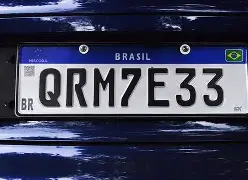

In [22]:
image = cv2.imread("/content/placa.png")
cv2_imshow(image)

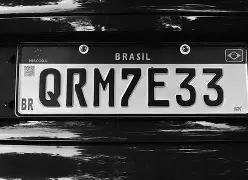

In [23]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
cv2_imshow(gray)

In [24]:
config_tesseract = "--tessdata-dir tessdata"
text = pytesseract.image_to_string(image, lang="por", config=config_tesseract)
print(text)

 

G

EE )

  

 



# Thresholding/limiarização simples

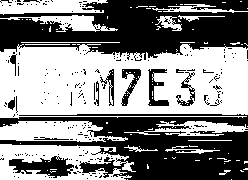

In [25]:
threshold = 25
value, trs_simple = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
cv2_imshow(trs_simple)

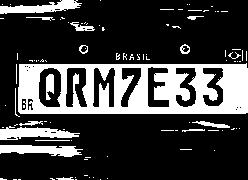

In [26]:
threshold = 127
value, trs_simple = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
cv2_imshow(trs_simple)

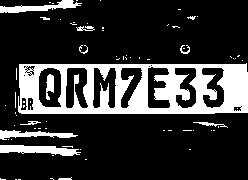

In [27]:
threshold = 170
value, trs_simple = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
cv2_imshow(trs_simple)

A IDEIA É NÃO FICAR USANDO PARAMETROS MANUAIS SEMPRE PRA FAZER O THRESHOLD

# Threshold Adaptativo

In [28]:
import numpy as np
from matplotlib import pyplot as plt

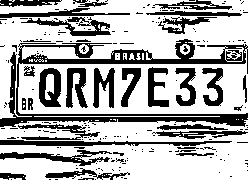

In [29]:
adaptive_th = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(adaptive_th)

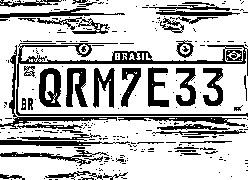

In [30]:
adaptive_th = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 8)
cv2_imshow(adaptive_th)

# Threshold de Otsu

array([[ 36,  18,  21, ...,  13,  16,  18],
       [ 17,  41,  28, ...,  19,  20,  17],
       [ 29,  14,  38, ...,  18,  15,  15],
       ...,
       [ 89,  59,  56, ...,  17,  17,  17],
       [186, 169, 133, ...,  17,  17,  17],
       [212, 225, 224, ...,  17,  17,  17]], dtype=uint8)
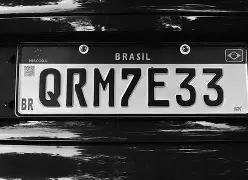

In [31]:
gray

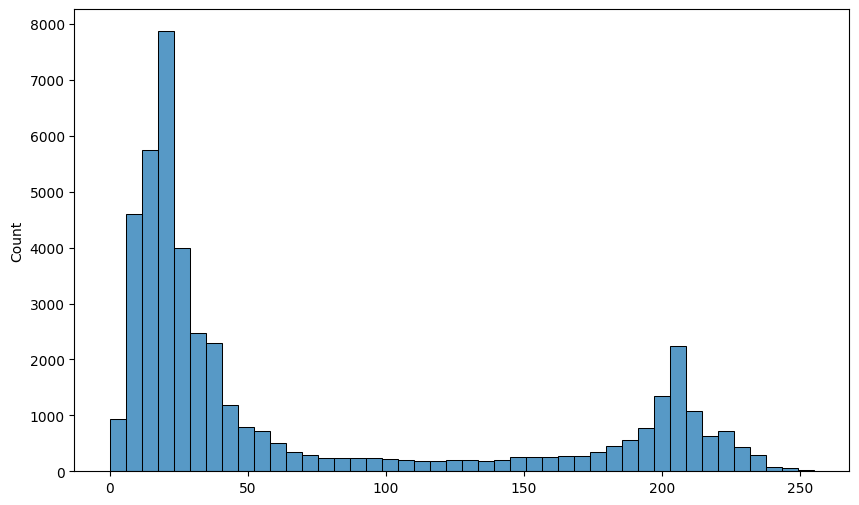

In [32]:
import seaborn as sns

#tem que transformar aquelas varias dimensoes em uma unica, e o flaten faz isso
ax = sns.histplot(gray.flatten())
ax.figure.set_size_inches(10, 6)

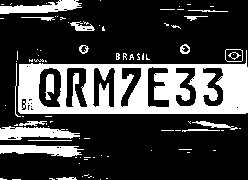

Threshold: 109.0


In [33]:
value, th_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
cv2_imshow(th_otsu)
print(f"Threshold: {value}")

In [34]:
config_tesseract = "--tessdata-dir tessdata"
text = pytesseract.image_to_string(th_otsu, lang="por", config = config_tesseract)
print(text)

Para entender melhor de meios para fazer o threshold, aqui trago exemplos de diferentes aplicações, como:

cv.THRESH_BINARY: Valor fixo x, caso a intensidade da cor do pixel seja maior que limiar, e 0 caso contrário

cv.THRESH_BINARY_INV: Valor fixo x, caso a intensidade da cor do pixel seja menor que limiar, e 0 caso contrário

cv.THRESH_TRUNC: Valor do limiar, caso a intensidade da cor do pixel seja maior que o limiar, e a intensidade original caso contrário

cv.THRESH_TOZERO: Intensidade original, caso a intensidade da cor do pixel seja maior que o limiar, e 0 caso contrário

cv.THRESH_TOZERO_INV: Intensidade original, caso a intensidade da cor do pixel seja menor que o limiar, e 0 caso contrário

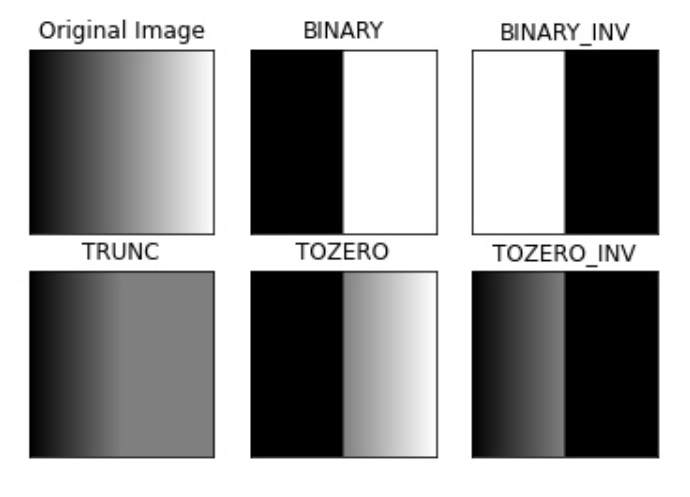

ATÉ AQUI, MESMO ESTUDANDO E ENTENDO CADA VEZ MAIS O PROCESSO DE THRESHOLDING SIMPLES, ADAPTATIVO E DE OTSU, NÃO ESTOU CONSEGUINDO LER A IMAGEM COM O PYTESSERACT. VAI SER NECESSÁRIO TRABALHAR MAIS O PREPROCESSAMENTO DA IMAGEM.

# Erosão e Dilatação

In [38]:
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

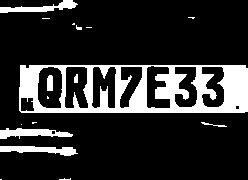

In [39]:
erosao = cv2.erode(th_otsu, kernel)
cv2_imshow(erosao)

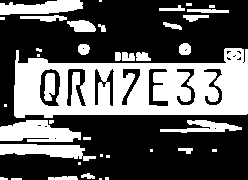

In [40]:
dilatacao = cv2.dilate(th_otsu, kernel)
cv2_imshow(dilatacao)